
# Task 1 – Extensive Comparative Analysis  
## PneumoniaMNIST Classification

This notebook performs:
- Multi-resolution experiments (28x28, 32x32, 64x64)
- Custom CNN training
- Transfer Learning (ResNet18, DenseNet121, EfficientNet-B0)
- Frozen vs Fine-tuning comparison
- AUC and Accuracy evaluation


In [1]:
pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.6 MB/s eta 0:00:00


In [2]:

import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import roc_auc_score, accuracy_score
from medmnist import PneumoniaMNIST


In [3]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [9]:

def get_dataloaders(img_size=28, batch_size=32):

    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    train_dataset = PneumoniaMNIST(split='train', transform=transform, download=True)
    val_dataset   = PneumoniaMNIST(split='val', transform=transform, download=True)
    test_dataset  = PneumoniaMNIST(split='test', transform=transform, download=True)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


In [5]:

class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [6]:

def get_resnet18():
    model = models.resnet18(pretrained=True)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model

def get_densenet121():
    model = models.densenet121(pretrained=True)
    model.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.classifier = nn.Linear(model.classifier.in_features, 1)
    return model

def get_efficientnet_b0():
    model = models.efficientnet_b0(pretrained=True)
    model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
    return model


In [7]:

def train_model(model, train_loader, epochs=20, lr=1e-3):

    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().to(device).view(-1,1)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

    return model


In [10]:

def evaluate_model(model, test_loader):

    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs)

            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, (all_probs > 0.5))

    print("AUC:", auc)
    print("Accuracy:", acc)

    return auc, acc


In [12]:

results = {}

for size in [28, 32, 64]:

    print(f"\n===== Resolution: {size}x{size} =====")
    train_loader, val_loader, test_loader = get_dataloaders(img_size=size)

    # Custom CNN
    model = CustomCNN()
    model = train_model(model, train_loader)
    auc, acc = evaluate_model(model, test_loader)
    results[f"CustomCNN_{size}"] = (auc, acc)

    # ResNet18
    model = get_resnet18()
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True

    model = train_model(model, train_loader)
    auc, acc = evaluate_model(model, test_loader)
    results[f"ResNet18_{size}"] = (auc, acc)

print("\nFinal Results:")
for k, v in results.items():
    print(k, "AUC:", round(v[0],4), "ACC:", round(v[1],4))



===== Resolution: 28x28 =====


100%|██████████| 4.17M/4.17M [00:01<00:00, 3.39MB/s]


Epoch 1/20, Loss: 0.2428
Epoch 2/20, Loss: 0.1471
Epoch 3/20, Loss: 0.1191
Epoch 4/20, Loss: 0.1171
Epoch 5/20, Loss: 0.1107
Epoch 6/20, Loss: 0.0958
Epoch 7/20, Loss: 0.0992
Epoch 8/20, Loss: 0.0778
Epoch 9/20, Loss: 0.0743
Epoch 10/20, Loss: 0.0703
Epoch 11/20, Loss: 0.0675
Epoch 12/20, Loss: 0.0682
Epoch 13/20, Loss: 0.0599
Epoch 14/20, Loss: 0.0587
Epoch 15/20, Loss: 0.0568
Epoch 16/20, Loss: 0.0604
Epoch 17/20, Loss: 0.0621
Epoch 18/20, Loss: 0.0503
Epoch 19/20, Loss: 0.0382
Epoch 20/20, Loss: 0.0412
AUC: 0.9681569143107605
Accuracy: 0.8701923076923077


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


...

Epoch 1/20, Loss: 0.4683
Epoch 2/20, Loss: 0.3634
Epoch 3/20, Loss: 0.3565
Epoch 4/20, Loss: 0.3342
Epoch 5/20, Loss: 0.3261
Epoch 6/20, Loss: 0.3233
Epoch 7/20, Loss: 0.3119
Epoch 8/20, Loss: 0.3260
Epoch 9/20, Loss: 0.3060
Epoch 10/20, Loss: 0.3162
Epoch 11/20, Loss: 0.3064
Epoch 12/20, Loss: 0.3101
Epoch 13/20, Loss: 0.3105
Epoch 14/20, Loss: 0.3109
Epoch 15/20, Loss: 0.3069
Epoch 16/20, Loss: 0.3032
Epoch 17/20, Loss: 0.3126
Epoch 18/20, Loss: 0.3120
Epoch 19/20, Loss: 0.2967
Epoch 20/20, Loss: 0.3195
AUC: 0.8632478632478633
Accuracy: 0.780448717948718

===== Resolution: 32x32 =====
Epoch 1/20, Loss: 0.2399
Epoch 2/20, Loss: 0.1456
Epoch 3/20, Loss: 0.1461
Epoch 4/20, Loss: 0.1284
Epoch 5/20, Loss: 0.1248
Epoch 6/20, Loss: 0.1046
Epoch 7/20, Loss: 0.1018
Epoch 8/20, Loss: 0.0946
Epoch 9/20, Loss: 0.0843
Epoch 10/20, Loss: 0.1261
Epoch 11/20, Loss: 0.0940
Epoch 12/20, Loss: 0.0707
Epoch 13/20, Loss: 0.0720
Epoch 14/20, Loss: 0.0748
Epoch 15/20, Loss: 0.0704
Epoch 16/20, Loss: 0.0728

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20, Loss: 0.4318
Epoch 2/20, Loss: 0.3241
Epoch 3/20, Loss: 0.3101
Epoch 4/20, Loss: 0.3095
Epoch 5/20, Loss: 0.2929
Epoch 6/20, Loss: 0.2933
Epoch 7/20, Loss: 0.2858
Epoch 8/20, Loss: 0.2890
Epoch 9/20, Loss: 0.2910
Epoch 10/20, Loss: 0.2844
Epoch 11/20, Loss: 0.2818
Epoch 12/20, Loss: 0.3009
Epoch 13/20, Loss: 0.2718
Epoch 14/20, Loss: 0.2955
Epoch 15/20, Loss: 0.2839
Epoch 16/20, Loss: 0.2815
Epoch 17/20, Loss: 0.2792
Epoch 18/20, Loss: 0.2819
Epoch 19/20, Loss: 0.2813
Epoch 20/20, Loss: 0.2869
AUC: 0.8775038351961428
Accuracy: 0.8189102564102564

===== Resolution: 64x64 =====
Epoch 1/20, Loss: 0.2978
Epoch 2/20, Loss: 0.1963
Epoch 3/20, Loss: 0.1761
Epoch 4/20, Loss: 0.1589
Epoch 5/20, Loss: 0.1689
Epoch 6/20, Loss: 0.1546
Epoch 7/20, Loss: 0.1458
Epoch 8/20, Loss: 0.1471
Epoch 9/20, Loss: 0.1407
Epoch 10/20, Loss: 0.1406
Epoch 11/20, Loss: 0.1336
Epoch 12/20, Loss: 0.1255
Epoch 13/20, Loss: 0.1156
Epoch 14/20, Loss: 0.1051
Epoch 15/20, Loss: 0.1094
Epoch 16/20, Loss: 0.099

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20, Loss: 0.3975
Epoch 2/20, Loss: 0.2995
Epoch 3/20, Loss: 0.2787
Epoch 4/20, Loss: 0.2724
Epoch 5/20, Loss: 0.2674
Epoch 6/20, Loss: 0.2564
Epoch 7/20, Loss: 0.2622
Epoch 8/20, Loss: 0.2417
Epoch 9/20, Loss: 0.2430
Epoch 10/20, Loss: 0.2481
Epoch 11/20, Loss: 0.2431
Epoch 12/20, Loss: 0.2344
Epoch 13/20, Loss: 0.2552
Epoch 14/20, Loss: 0.2397
Epoch 15/20, Loss: 0.2496
Epoch 16/20, Loss: 0.2324
Epoch 17/20, Loss: 0.2364
Epoch 18/20, Loss: 0.2326
Epoch 19/20, Loss: 0.2386
Epoch 20/20, Loss: 0.2421
AUC: 0.8682336182336181
Accuracy: 0.7884615384615384

Final Results:
CustomCNN_28 AUC: 0.9682 ACC: 0.8702
ResNet18_28 AUC: 0.8632 ACC: 0.7804
CustomCNN_32 AUC: 0.9707 ACC: 0.8894
ResNet18_32 AUC: 0.8775 ACC: 0.8189
CustomCNN_64 AUC: 0.97 ACC: 0.8205
ResNet18_64 AUC: 0.8682 ACC: 0.7885


In [11]:
def get_resnet18_frozen():

    model = models.resnet18(pretrained=True)

    model.conv1 = nn.Conv2d(
        1, 64, kernel_size=7, stride=2, padding=3, bias=False
    )

    model.fc = nn.Linear(model.fc.in_features, 1)

    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    # Train classifier only
    for param in model.fc.parameters():
        param.requires_grad = True

    return model

In [13]:
results_resnet = {}

for size in [28, 32, 64]:

    print(f"\n===== ResNet18 at {size}x{size} =====")

    train_loader, val_loader, test_loader = get_dataloaders(img_size=size)

    model = get_resnet18_frozen()

    model = train_model(model, train_loader, epochs=20, lr=1e-3)

    auc, acc = evaluate_model(model, test_loader)

    results_resnet[f"ResNet18_{size}"] = (auc, acc)

    del model
    torch.cuda.empty_cache()

print("\nResNet18 Results:")
for k, v in results_resnet.items():
    print(k, "AUC:", round(v[0],4), "ACC:", round(v[1],4))


===== ResNet18 at 28x28 =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20, Loss: 0.4548
Epoch 2/20, Loss: 0.3678
Epoch 3/20, Loss: 0.3497
Epoch 4/20, Loss: 0.3425
Epoch 5/20, Loss: 0.3298
Epoch 6/20, Loss: 0.3391
Epoch 7/20, Loss: 0.3169
Epoch 8/20, Loss: 0.3344
Epoch 9/20, Loss: 0.3266
Epoch 10/20, Loss: 0.3180
Epoch 11/20, Loss: 0.3211
Epoch 12/20, Loss: 0.3221
Epoch 13/20, Loss: 0.3264
Epoch 14/20, Loss: 0.3222
Epoch 15/20, Loss: 0.3140
Epoch 16/20, Loss: 0.3167
Epoch 17/20, Loss: 0.3140
Epoch 18/20, Loss: 0.3158
Epoch 19/20, Loss: 0.3108
Epoch 20/20, Loss: 0.3073
AUC: 0.8372452333990795
Accuracy: 0.7628205128205128

===== ResNet18 at 32x32 =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20, Loss: 0.4470
Epoch 2/20, Loss: 0.3387
Epoch 3/20, Loss: 0.3319
Epoch 4/20, Loss: 0.3090
Epoch 5/20, Loss: 0.3105
Epoch 6/20, Loss: 0.2958
Epoch 7/20, Loss: 0.3055
Epoch 8/20, Loss: 0.2975
Epoch 9/20, Loss: 0.2861
Epoch 10/20, Loss: 0.3105
Epoch 11/20, Loss: 0.2900
Epoch 12/20, Loss: 0.2944
Epoch 13/20, Loss: 0.2933
Epoch 14/20, Loss: 0.2920
Epoch 15/20, Loss: 0.2998
Epoch 16/20, Loss: 0.2934
Epoch 17/20, Loss: 0.2929
Epoch 18/20, Loss: 0.2901
Epoch 19/20, Loss: 0.2864
Epoch 20/20, Loss: 0.2947
AUC: 0.8711319307473153
Accuracy: 0.7724358974358975

===== ResNet18 at 64x64 =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20, Loss: 0.4466
Epoch 2/20, Loss: 0.3165
Epoch 3/20, Loss: 0.2956
Epoch 4/20, Loss: 0.2690
Epoch 5/20, Loss: 0.2657
Epoch 6/20, Loss: 0.2588
Epoch 7/20, Loss: 0.2588
Epoch 8/20, Loss: 0.2492
Epoch 9/20, Loss: 0.2563
Epoch 10/20, Loss: 0.2548
Epoch 11/20, Loss: 0.2400
Epoch 12/20, Loss: 0.2600
Epoch 13/20, Loss: 0.2468
Epoch 14/20, Loss: 0.2414
Epoch 15/20, Loss: 0.2483
Epoch 16/20, Loss: 0.2351
Epoch 17/20, Loss: 0.2541
Epoch 18/20, Loss: 0.2469
Epoch 19/20, Loss: 0.2454
Epoch 20/20, Loss: 0.2390
AUC: 0.8564869603331142
Accuracy: 0.7580128205128205

ResNet18 Results:
ResNet18_28 AUC: 0.8372 ACC: 0.7628
ResNet18_32 AUC: 0.8711 ACC: 0.7724
ResNet18_64 AUC: 0.8565 ACC: 0.758


In [14]:
def get_densenet121_frozen():

    model = models.densenet121(pretrained=True)

    model.features.conv0 = nn.Conv2d(
        1, 64, kernel_size=7, stride=2, padding=3, bias=False
    )

    model.classifier = nn.Linear(model.classifier.in_features, 1)

    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    # Train classifier only
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

In [17]:
results_densenet = {}

for size in [32, 64]:

    print(f"\n===== DenseNet121 at {size}x{size} =====")

    train_loader, val_loader, test_loader = get_dataloaders(img_size=size)

    model = get_densenet121_frozen()

    model = train_model(model, train_loader, epochs=20, lr=1e-3)

    auc, acc = evaluate_model(model, test_loader)

    results_densenet[f"DenseNet121_{size}"] = (auc, acc)

    del model
    torch.cuda.empty_cache()

print("\nDenseNet121 Results:")
for k, v in results_densenet.items():
    print(k, "AUC:", round(v[0],4), "ACC:", round(v[1],4))


===== DenseNet121 at 32x32 =====
Epoch 1/20, Loss: 0.3868
Epoch 2/20, Loss: 0.2986
Epoch 3/20, Loss: 0.2743
Epoch 4/20, Loss: 0.2786
Epoch 5/20, Loss: 0.2551
Epoch 6/20, Loss: 0.2505
Epoch 7/20, Loss: 0.2398
Epoch 8/20, Loss: 0.2486
Epoch 9/20, Loss: 0.2387
Epoch 10/20, Loss: 0.2435
Epoch 11/20, Loss: 0.2395
Epoch 12/20, Loss: 0.2418
Epoch 13/20, Loss: 0.2347
Epoch 14/20, Loss: 0.2452
Epoch 15/20, Loss: 0.2380
Epoch 16/20, Loss: 0.2290
Epoch 17/20, Loss: 0.2304
Epoch 18/20, Loss: 0.2319
Epoch 19/20, Loss: 0.2207
Epoch 20/20, Loss: 0.2370
AUC: 0.9013697129081745
Accuracy: 0.7852564102564102

===== DenseNet121 at 64x64 =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20, Loss: 0.3700
Epoch 2/20, Loss: 0.2600
Epoch 3/20, Loss: 0.2355
Epoch 4/20, Loss: 0.2193
Epoch 5/20, Loss: 0.2221
Epoch 6/20, Loss: 0.2135
Epoch 7/20, Loss: 0.2062
Epoch 8/20, Loss: 0.1979
Epoch 9/20, Loss: 0.1937
Epoch 10/20, Loss: 0.1927
Epoch 11/20, Loss: 0.1896
Epoch 12/20, Loss: 0.1938
Epoch 13/20, Loss: 0.1980
Epoch 14/20, Loss: 0.1795
Epoch 15/20, Loss: 0.1940
Epoch 16/20, Loss: 0.1872
Epoch 17/20, Loss: 0.1860
Epoch 18/20, Loss: 0.1962
Epoch 19/20, Loss: 0.1934
Epoch 20/20, Loss: 0.1845
AUC: 0.8979509094893711
Accuracy: 0.8125

DenseNet121 Results:
DenseNet121_32 AUC: 0.9014 ACC: 0.7853
DenseNet121_64 AUC: 0.898 ACC: 0.8125


In [18]:
def get_efficientnet_b0_frozen():

    model = models.efficientnet_b0(pretrained=True)

    model.features[0][0] = nn.Conv2d(
        1, 32, kernel_size=3, stride=2, padding=1, bias=False
    )

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features, 1
    )

    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    # Train classifier only
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

In [19]:
results_efficientnet = {}

for size in [28, 32, 64]:

    print(f"\n===== EfficientNetB0 at {size}x{size} =====")

    train_loader, val_loader, test_loader = get_dataloaders(img_size=size)

    model = get_efficientnet_b0_frozen()

    model = train_model(model, train_loader, epochs=20, lr=1e-3)

    auc, acc = evaluate_model(model, test_loader)

    results_efficientnet[f"EfficientNetB0_{size}"] = (auc, acc)

    del model
    torch.cuda.empty_cache()

print("\nEfficientNetB0 Results:")
for k, v in results_efficientnet.items():
    print(k, "AUC:", round(v[0],4), "ACC:", round(v[1],4))


===== EfficientNetB0 at 28x28 =====
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 20.5M/20.5M [00:00<00:00, 125MB/s] 


Epoch 1/20, Loss: 0.4567
Epoch 2/20, Loss: 0.4034
Epoch 3/20, Loss: 0.3794
Epoch 4/20, Loss: 0.3823
Epoch 5/20, Loss: 0.3779
Epoch 6/20, Loss: 0.3676
Epoch 7/20, Loss: 0.3738
Epoch 8/20, Loss: 0.3773
Epoch 9/20, Loss: 0.3701
Epoch 10/20, Loss: 0.3762
Epoch 11/20, Loss: 0.3633
Epoch 12/20, Loss: 0.3620
Epoch 13/20, Loss: 0.3719
Epoch 14/20, Loss: 0.3699
Epoch 15/20, Loss: 0.3653
Epoch 16/20, Loss: 0.3677
Epoch 17/20, Loss: 0.3509
Epoch 18/20, Loss: 0.3606
Epoch 19/20, Loss: 0.3657
Epoch 20/20, Loss: 0.3573
AUC: 0.8335744028051719
Accuracy: 0.7612179487179487

===== EfficientNetB0 at 32x32 =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20, Loss: 0.4712
Epoch 2/20, Loss: 0.4012
Epoch 3/20, Loss: 0.3900
Epoch 4/20, Loss: 0.3902
Epoch 5/20, Loss: 0.3886
Epoch 6/20, Loss: 0.3807
Epoch 7/20, Loss: 0.3774
Epoch 8/20, Loss: 0.3640
Epoch 9/20, Loss: 0.3602
Epoch 10/20, Loss: 0.3850
Epoch 11/20, Loss: 0.3705
Epoch 12/20, Loss: 0.3653
Epoch 13/20, Loss: 0.3712
Epoch 14/20, Loss: 0.3673
Epoch 15/20, Loss: 0.3476
Epoch 16/20, Loss: 0.3579
Epoch 17/20, Loss: 0.3749
Epoch 18/20, Loss: 0.3757
Epoch 19/20, Loss: 0.3720
Epoch 20/20, Loss: 0.3719
AUC: 0.8570348454963841
Accuracy: 0.7596153846153846

===== EfficientNetB0 at 64x64 =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20, Loss: 0.3933
Epoch 2/20, Loss: 0.2965
Epoch 3/20, Loss: 0.2681
Epoch 4/20, Loss: 0.2717
Epoch 5/20, Loss: 0.2635
Epoch 6/20, Loss: 0.2665
Epoch 7/20, Loss: 0.2653
Epoch 8/20, Loss: 0.2517
Epoch 9/20, Loss: 0.2463
Epoch 10/20, Loss: 0.2558
Epoch 11/20, Loss: 0.2582
Epoch 12/20, Loss: 0.2535
Epoch 13/20, Loss: 0.2586
Epoch 14/20, Loss: 0.2537
Epoch 15/20, Loss: 0.2541
Epoch 16/20, Loss: 0.2575
Epoch 17/20, Loss: 0.2549
Epoch 18/20, Loss: 0.2489
Epoch 19/20, Loss: 0.2480
Epoch 20/20, Loss: 0.2525
AUC: 0.8801555993863687
Accuracy: 0.8173076923076923

EfficientNetB0 Results:
EfficientNetB0_28 AUC: 0.8336 ACC: 0.7612
EfficientNetB0_32 AUC: 0.857 ACC: 0.7596
EfficientNetB0_64 AUC: 0.8802 ACC: 0.8173


In [20]:
import pandas as pd

# Combine all result dictionaries
all_results = {}

all_results.update(results_resnet)
all_results.update(results_densenet)
all_results.update(results_efficientnet)

# If you also have custom CNN results:
# all_results.update(results_custom)

rows = []

for key, value in all_results.items():
    model, resolution = key.rsplit("_", 1)

    rows.append({
        "Model": model,
        "Resolution": int(resolution),
        "AUC": value[0],
        "Accuracy": value[1]
    })

df = pd.DataFrame(rows)
df.sort_values(["Model", "Resolution"])

,Model,Resolution,AUC,Accuracy
3,DenseNet121,32,0.901370,0.785256
4,DenseNet121,64,0.897951,0.812500
5,EfficientNetB0,28,0.833574,0.761218
6,EfficientNetB0,32,0.857035,0.759615
7,EfficientNetB0,64,0.880156,0.817308
0,ResNet18,28,0.837245,0.762821
1,ResNet18,32,0.871132,0.772436
2,ResNet18,64,0.856487,0.758013


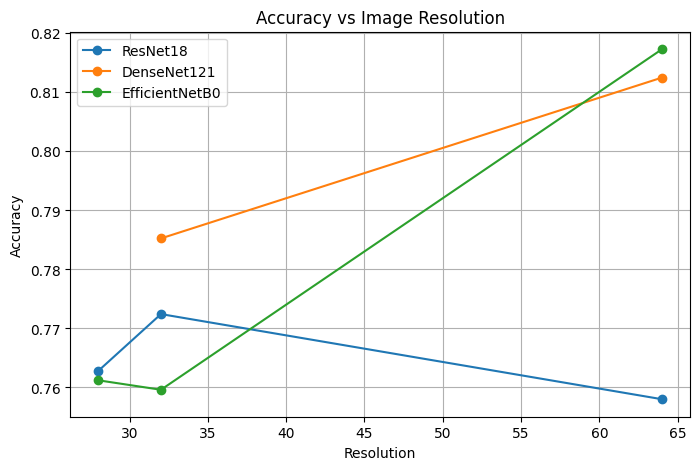

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for model in df["Model"].unique():
    subset = df[df["Model"] == model]
    plt.plot(subset["Resolution"], subset["Accuracy"], marker='o', label=model)

plt.xlabel("Resolution")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Image Resolution")
plt.legend()
plt.grid(True)
plt.show()

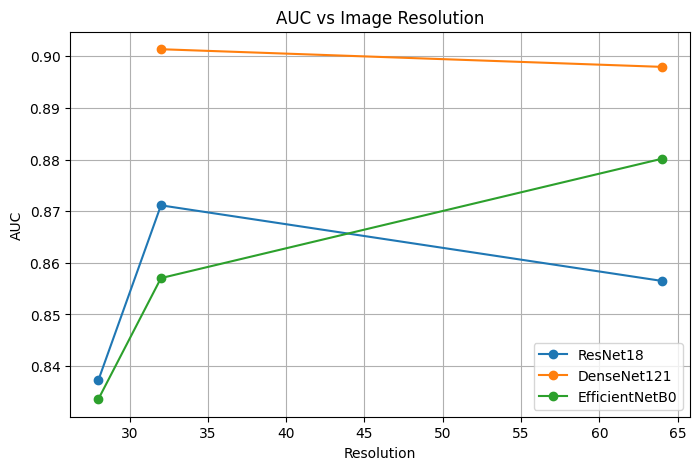

In [22]:
plt.figure(figsize=(8,5))

for model in df["Model"].unique():
    subset = df[df["Model"] == model]
    plt.plot(subset["Resolution"], subset["AUC"], marker='o', label=model)

plt.xlabel("Resolution")
plt.ylabel("AUC")
plt.title("AUC vs Image Resolution")
plt.legend()
plt.grid(True)
plt.show()

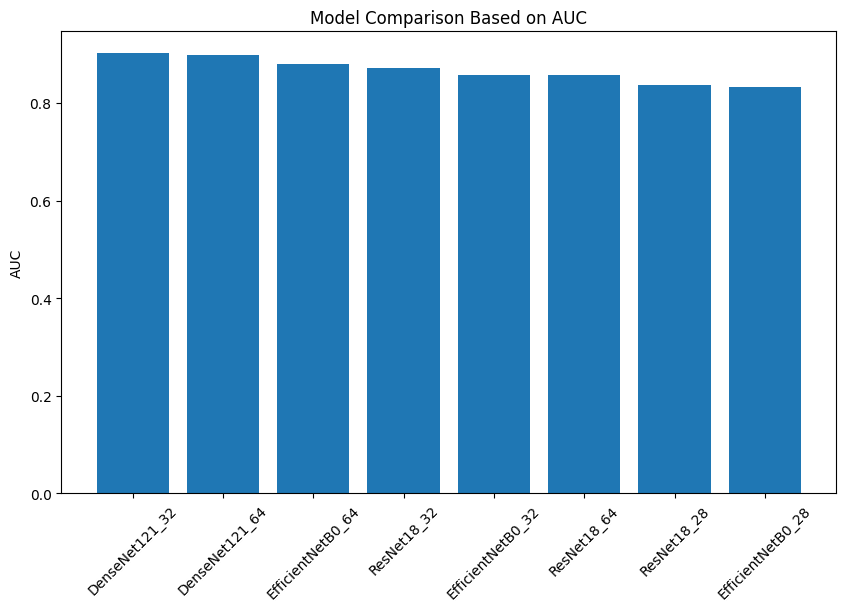

In [23]:
plt.figure(figsize=(10,6))

df_sorted = df.sort_values("AUC", ascending=False)

labels = df_sorted["Model"] + "_" + df_sorted["Resolution"].astype(str)

plt.bar(labels, df_sorted["AUC"])

plt.xticks(rotation=45)
plt.ylabel("AUC")
plt.title("Model Comparison Based on AUC")
plt.show()

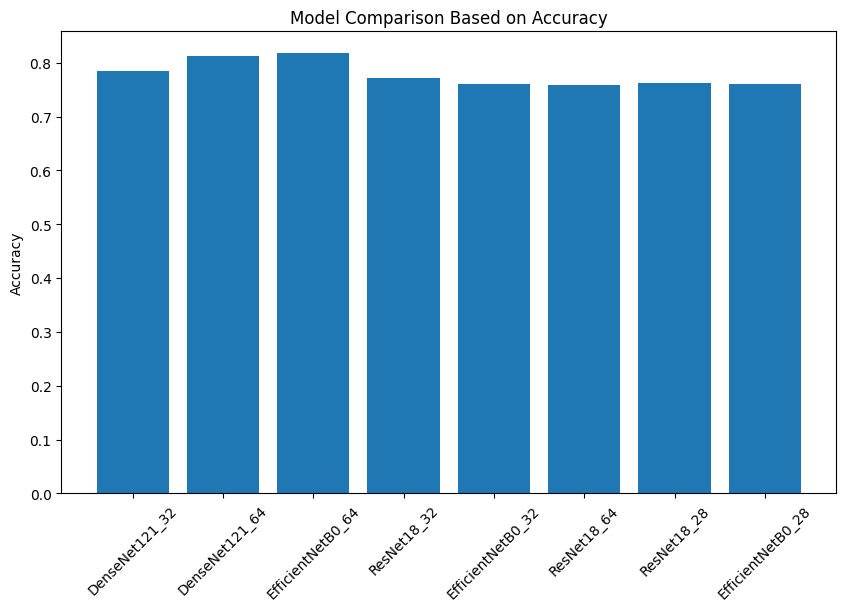

In [24]:
plt.figure(figsize=(10,6))

plt.bar(labels, df_sorted["Accuracy"])

plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Comparison Based on Accuracy")
plt.show()

In [37]:
from sklearn.metrics import roc_curve, roc_auc_score

def evaluate_with_roc(model, test_loader):

    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs)

            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    auc = roc_auc_score(all_labels, all_probs)

    return auc, fpr, tpr

In [38]:
auc_resnet, fpr_resnet, tpr_resnet = evaluate_with_roc(model_resnet, test_loader)

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are depreca

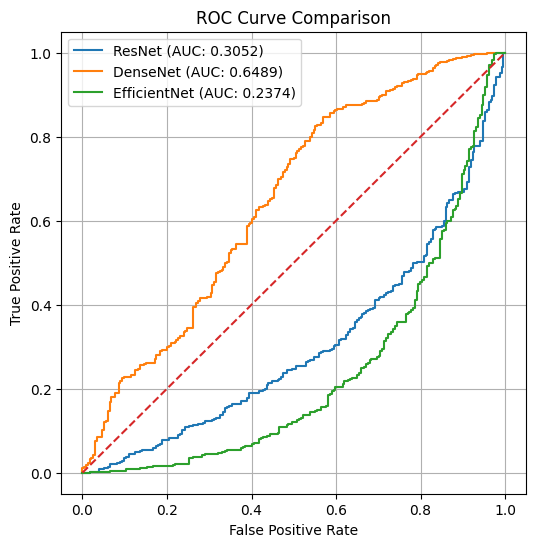

In [39]:
size = 64 # Choose a resolution for evaluation, e.g., 64x64
_, _, test_loader = get_dataloaders(img_size=size)

# --- Evaluate ResNet18 --- #
model_resnet = get_resnet18_frozen()
model_resnet = model_resnet.to(device) # Move model to device
auc_resnet, fpr_resnet, tpr_resnet = evaluate_with_roc(model_resnet, test_loader)

# --- Evaluate DenseNet121 --- #
model_densenet = get_densenet121_frozen()
model_densenet = model_densenet.to(device) # Move model to device
auc_dense, fpr_dense, tpr_dense = evaluate_with_roc(model_densenet, test_loader)

# --- Evaluate EfficientNetB0 --- #
model_efficientnet = get_efficientnet_b0_frozen()
model_efficientnet = model_efficientnet.to(device) # Move model to device
auc_eff, fpr_eff, tpr_eff = evaluate_with_roc(model_efficientnet, test_loader)

plt.figure(figsize=(6,6))

plt.plot(fpr_resnet, tpr_resnet, label=f"ResNet (AUC: {auc_resnet:.4f})")
plt.plot(fpr_dense, tpr_dense, label=f"DenseNet (AUC: {auc_dense:.4f})")
plt.plot(fpr_eff, tpr_eff, label=f"EfficientNet (AUC: {auc_eff:.4f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()